In [1]:
import xarray as xr
import pandas as pd
import numpy as np

In [2]:
import os
os.getcwd()

'/home/jovyan/signal-extraction/workbench'

In [3]:
pdata = xr.open_dataset("~/signal-extraction/results/ERA5_GAMMA/ERA5_GAMMA_extractr_results_precip.nc")

In [4]:
pdata

<xarray.Dataset> Size: 1MB
Dimensions:    (time: 1026, latitude: 17, longitude: 17)
Coordinates:
  * time       (time) datetime64[ns] 8kB 1940-01-16 ... 2025-06-15T12:00:00
  * latitude   (latitude) float64 136B 40.0 39.75 39.5 39.25 ... 36.5 36.25 36.0
  * longitude  (longitude) float64 136B -123.0 -122.8 -122.5 ... -119.2 -119.0
Data variables:
    precip     (time, latitude, longitude) float32 1MB ...

In [5]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot

# ---------------------------
# LOAD AND PREPARE DATA
# ---------------------------

# Extract precipitation as a flattened 1D array
# pdata is your loaded xarray Dataset
precip = pdata["precip"].values  # shape (time, lat, lon)
precip_flat = precip.flatten()

# Remove invalids
precip_flat = precip_flat[~np.isnan(precip_flat)]

# For transformations
precip_log = np.log1p(precip_flat)  # log(1 + precip)


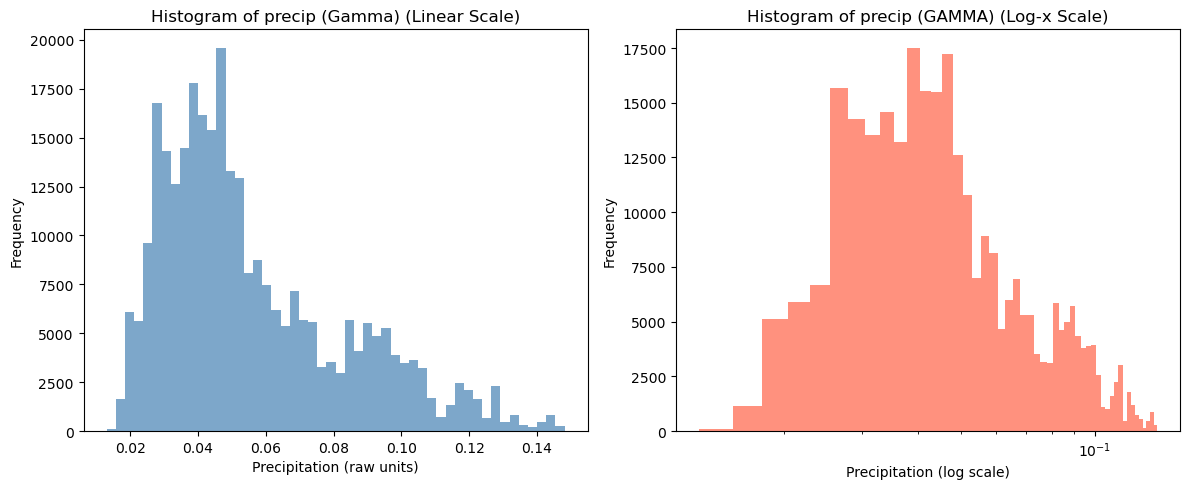

In [6]:

plt.figure(figsize=(12,5))

# Linear histogram
plt.subplot(1,2,1)
plt.hist(precip_flat, bins=50, color='steelblue', alpha=0.7)
plt.xlabel("Precipitation (raw units)")
plt.ylabel("Frequency")
plt.title("Histogram of precip (Gamma) (Linear Scale)")

# Log-x histogram
plt.subplot(1,2,2)
plt.hist(precip_log, bins=50, color='tomato', alpha=0.7)
plt.xscale("log")
plt.xlabel("Precipitation (log scale)")
plt.ylabel("Frequency")
plt.title("Histogram of precip (GAMMA) (Log-x Scale)")

plt.tight_layout()
plt.show()


In [8]:
latent = pd.read_csv("~/signal-extraction/results/ERA5_GNLL/ERA5_GNLL_extractr_results_latent_full.csv")

In [18]:
def latentKDE( var: str, model:str, path: str):
    latent = pd.read_csv(f"~/{path}")
    plt.figure(figsize=(8,5))
    sns.kdeplot(latent[var].values, fill=True)
    plt.xlabel(f"{var}")
    plt.title(f"KDE of {model} Latent Index ({var})")
    plt.show()

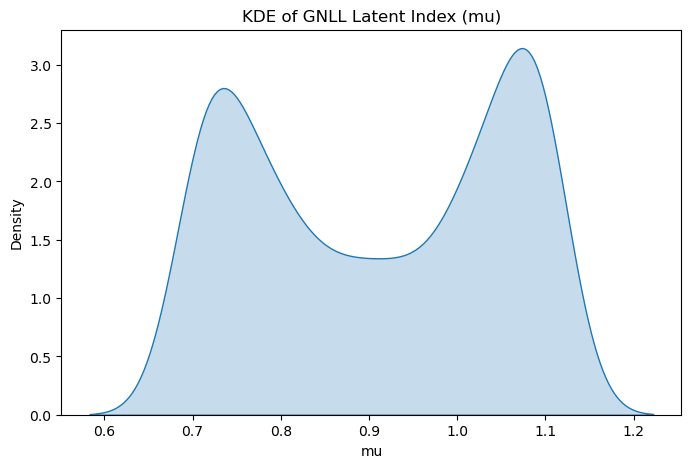

In [20]:
latentKDE('mu','GNLL', 'signal-extraction/results/ERA5_GNLL/ERA5_GNLL_extractr_results_latent_full.csv')

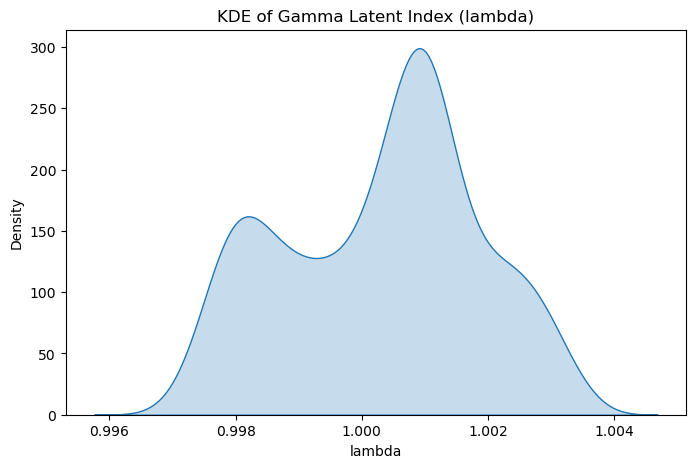

In [21]:
latentKDE('lambda', 'Gamma', 'signal-extraction/results/ERA5_GAMMA/ERA5_GAMMA_extractr_results_latent_full.csv')

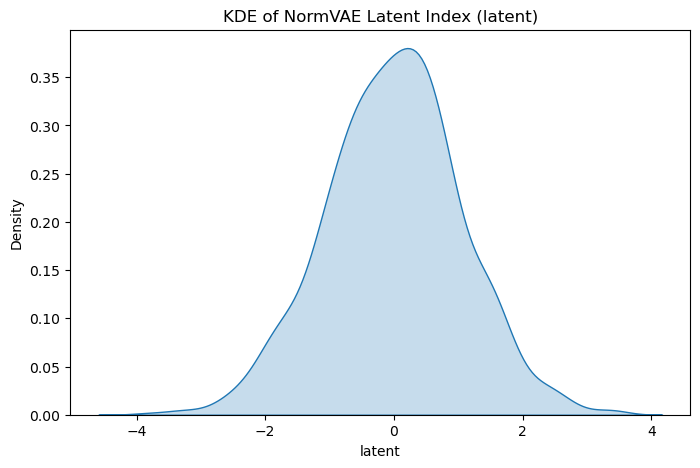

In [22]:
latentKDE('latent','NormVAE', 'signal-extraction/results/ERA5_norm_vae/ERA5_norm_vae_extractr_results_latent_full.csv')

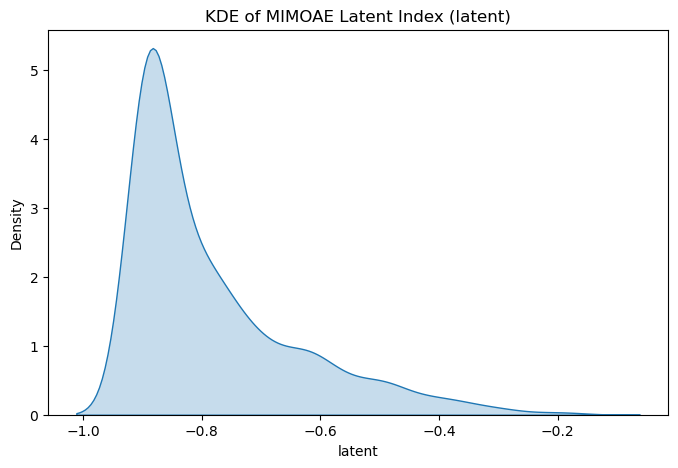

In [23]:
latentKDE('latent','MIMOAE','signal-extraction/results/MIMOAE/mon_mean_sst-mon_sum_tp-mm.csv')

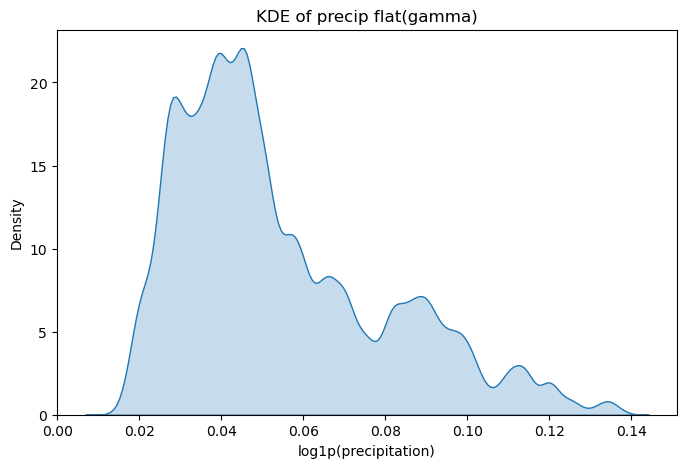

In [7]:
plt.figure(figsize=(8,5))
sns.kdeplot(precip_log, fill=True)
plt.xlabel("log1p(precipitation)")
plt.title("KDE of precip flat(gamma)")
plt.show()

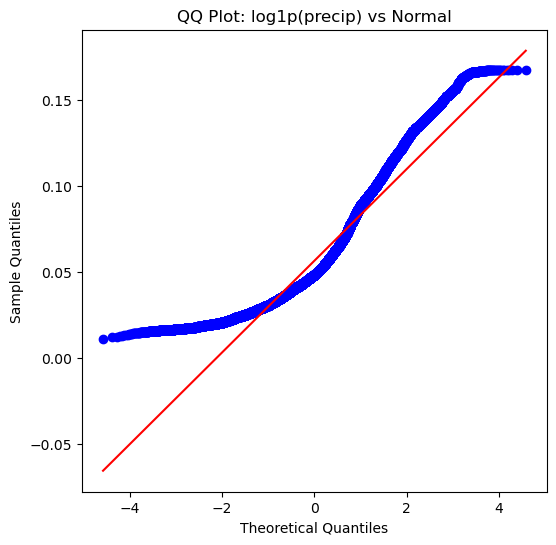

In [25]:
plt.figure(figsize=(6,6))
probplot(precip_log, dist="norm", plot=plt)
plt.title("QQ Plot: log1p(precip) vs Normal")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

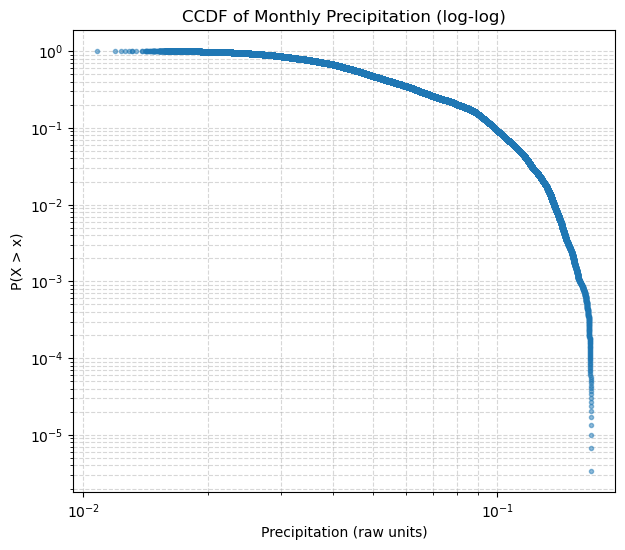

In [26]:
# Sort data
sorted_precip = np.sort(precip_flat)

# CCDF = P(X > x)
ccdf = 1.0 - np.arange(1, len(sorted_precip)+1) / len(sorted_precip)

plt.figure(figsize=(7,6))
plt.loglog(sorted_precip, ccdf, marker='.', linestyle='none', alpha=0.5)
plt.xlabel("Precipitation (raw units)")
plt.ylabel("P(X > x)")
plt.title("CCDF of Monthly Precipitation (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()
